Вариант 2: эмоциональный анализ текста+ подбор гиперпараметров(отзывы)

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

set_seed(42)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Устройство: cuda


Датасет отзывов:

In [18]:
data = []

positive_templates = [
    "Мне очень понравился {}",
    "Отличный {}",
    "Очень доволен {}",
    "Качество {} на высоте",
    "Прекрасный {}",
    "Рекомендую {}",
    "Замечательный {}",
    "Все прошло отлично, {}",
]

negative_templates = [
    "Мне не понравился {}",
    "Ужасный {}",
    "Очень разочарован {}",
    "Качество {} плохое",
    "Отвратительный {}",
    "Не рекомендую {}",
    "Очень плохой {}",
    "Все прошло ужасно, {}",
]

objects = [
    "сервис", "фильм", "товар", "сайт", "продукт",
    "магазин", "заказ", "опыт", "интерфейс", "контент"
]

# генерируем данные
for obj in objects:
    for t in positive_templates:
        data.append((t.format(obj), 1))
    for t in negative_templates:
        data.append((t.format(obj), 0))

df = pd.DataFrame(data, columns=["text", "labels"])

print("Размер датасета:", len(df))
print(df.head())

Размер датасета: 160
                          text  labels
0  Мне очень понравился сервис       1
1              Отличный сервис       1
2         Очень доволен сервис       1
3    Качество сервис на высоте       1
4            Прекрасный сервис       1


Разбиение на тестовые+обучение+валидация

In [19]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["labels"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["labels"]
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

Train: 96
Val: 32
Test: 32


Загружается токенизатор и компактная русскоязычная трансформерная модель на основе архитектуры BERT. Модель адаптируется под задачу бинарной классификации текстов.

In [25]:
model_checkpoint = "cointegrated/rubert-tiny2"
#model_checkpoint = "DeepPavlov/rubert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
).to(device)

print("Модель загружена")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Модель загружена


Токенизация датасета, текстовые данные преобразуются в числовое представление

In [26]:
MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Определение метрик качества

In [22]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(probs, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )
    acc = accuracy_score(labels, preds)
    roc_auc = roc_auc_score(labels, probs[:, 1])
    pr_auc = average_precision_score(labels, probs[:, 1])

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

Настройка гиперпараметров

In [28]:
training_args = TrainingArguments(
    output_dir="./sentiment_results",

    learning_rate=3e-5,  # немного выше
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=15,  # БОЛЬШЕ эпох
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_steps=10,
    report_to="none",

    fp16=torch.cuda.is_available()
)

ОБучение модели, оценка на валидационных данных

In [29]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

train_result = trainer.train()
print(train_result)

print("\nОценка на validation:")
val_metrics = trainer.evaluate(tokenized_val)
print(val_metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Pr Auc
1,No log,0.660706,0.812500,0.727273,1.000000,0.842105,0.968750,0.972917
2,0.667944,0.632507,0.968750,0.941176,1.000000,0.969697,1.000000,1.000000
3,0.667944,0.594948,0.968750,0.941176,1.000000,0.969697,1.000000,1.000000
4,0.620143,0.547729,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.554955,0.495056,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,0.554955,0.440834,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,0.472192,0.389008,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,0.472192,0.342171,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,0.383193,0.302803,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
10,0.335783,0.271332,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=90, training_loss=0.42410074869791664, metrics={'train_runtime': 243.9094, 'train_samples_per_second': 5.904, 'train_steps_per_second': 0.369, 'total_flos': 144488367936.0, 'train_loss': 0.42410074869791664, 'epoch': 15.0})

Оценка на validation:


{'eval_loss': 0.546539306640625, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_roc_auc': 1.0, 'eval_pr_auc': 1.0, 'eval_runtime': 0.0244, 'eval_samples_per_second': 1313.722, 'eval_steps_per_second': 82.108, 'epoch': 15.0}


In [30]:
print("Оценка на test:")
test_metrics = trainer.evaluate(tokenized_test)
print(test_metrics)

pred_output = trainer.predict(tokenized_test)
test_logits = pred_output.predictions
test_labels = pred_output.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_preds = np.argmax(test_probs, axis=-1)

print("\nClassification report:")
print(classification_report(test_labels, test_preds, target_names=["NEGATIVE", "POSITIVE"]))

Оценка на test:


{'eval_loss': 0.5746612548828125, 'eval_accuracy': 0.875, 'eval_precision': 0.8333333333333334, 'eval_recall': 0.9375, 'eval_f1': 0.8823529411764706, 'eval_roc_auc': 0.9609375, 'eval_pr_auc': 0.9635690789473685, 'eval_runtime': 0.0319, 'eval_samples_per_second': 1002.598, 'eval_steps_per_second': 62.662, 'epoch': 15.0}

Classification report:
              precision    recall  f1-score   support

    NEGATIVE       0.93      0.81      0.87        16
    POSITIVE       0.83      0.94      0.88        16

    accuracy                           0.88        32
   macro avg       0.88      0.88      0.87        32
weighted avg       0.88      0.88      0.87        32



<Figure size 500x400 with 0 Axes>

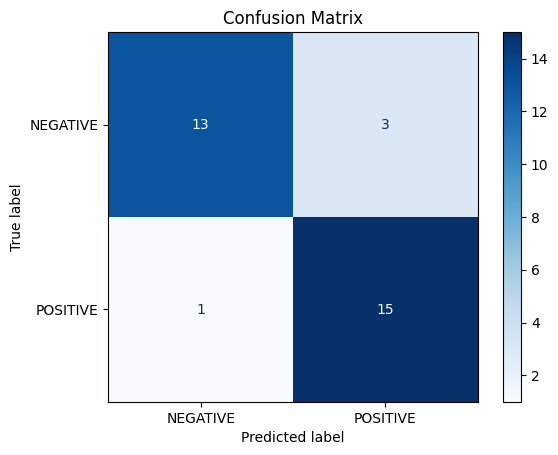

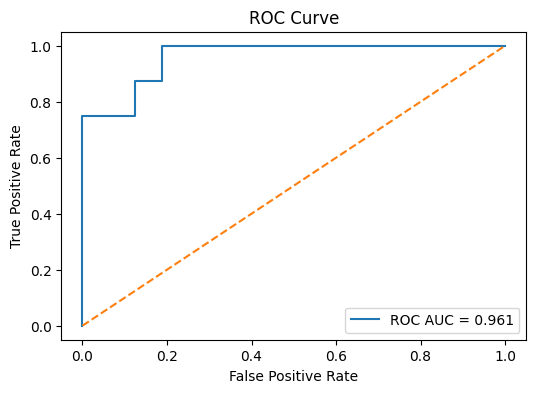

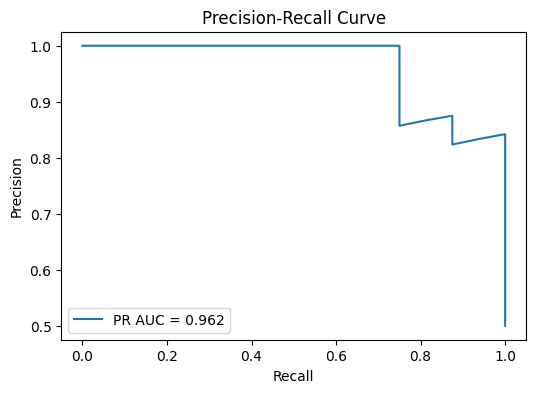

In [31]:
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NEGATIVE", "POSITIVE"])

plt.figure(figsize=(5, 4))
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(test_labels, test_probs[:, 1])
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(test_labels, test_probs[:, 1])
pr_auc_val = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc_val:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [32]:
new_texts = [
    "Мне очень понравился этот сервис, всё работает быстро и удобно.",
    "Ужасный опыт, больше пользоваться не буду.",
    "Всё нормально, без особых эмоций.",
    "Качество отличное, я доволен покупкой."
]

inputs = tokenizer(new_texts, truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors="pt").to(device)

model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
    preds = np.argmax(probs, axis=-1)

for text, pred, prob in zip(new_texts, preds, probs):
    print("Текст:", text)
    print("Предсказание:", id2label[int(pred)], "| probs =", np.round(prob, 3))
    print("-" * 80)

Текст: Мне очень понравился этот сервис, всё работает быстро и удобно.
Предсказание: POSITIVE | probs = [0.467 0.533]
--------------------------------------------------------------------------------
Текст: Ужасный опыт, больше пользоваться не буду.
Предсказание: NEGATIVE | probs = [0.569 0.431]
--------------------------------------------------------------------------------
Текст: Всё нормально, без особых эмоций.
Предсказание: POSITIVE | probs = [0.486 0.514]
--------------------------------------------------------------------------------
Текст: Качество отличное, я доволен покупкой.
Предсказание: POSITIVE | probs = [0.4 0.6]
--------------------------------------------------------------------------------


In [33]:
save_path = "./sentiment_model_final"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Сохранено в:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Сохранено в: ./sentiment_model_final
